In [ ]:
#!/usr/bin/env python3
"""
SPIKE-FEATURE SUBSET SEARCH (TRAIN-ONLY EOF basis)
==================================================
Goal:
  Given a "feature_ranking.csv" (ordered list of features) and a "r2_spikes_top10.txt"
  (spike positions n = number of features in the incremental curve),
  find which COMBINATIONS of the spike features give the highest TEST R².

Key design choice (important for fair comparison):
  - We evaluate ALL subsets on the SAME sample window by using a GLOBAL_MAXLAG
    (max lag among spike features). This keeps train/test years identical across subsets.

Outputs:
  - best_subsets_by_k.csv  : best subset for k=1..K
  - all_subsets_scored.csv : all tested subsets with R² and corr (can get big if many spikes)
"""

import os
import re
import itertools
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "CESM2"  # "CESM2" or "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"        # "ensmean" or "member"
member_id = None          # if MODE="member", set label/index

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Inputs you provided
RANK_CSV  = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/simple_ranking/feature_ranking_trainval.csv"
SPIKES_TXT = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/simple_ranking/04_r2_spikes_top10.txt"

# Output folder
OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_SUBSET_SEARCH/"
os.makedirs(OUTDIR, exist_ok=True)

# PC setup
N_MODES = 10

# Model hyperparams (match your reconstruction)
ALPHA = 50  # set to match the run tag A50 (change if needed)

DETREND_Y = True
DETREND_X = True

# Subset search settings
MAX_FEATURES_TO_USE = 10        # 1..10 features per reconstruction
SAVE_ALL_SUBSETS = True         # if False: only saves best by k

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" in y.dims:
        am = y
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am = am.astype(float)

    if "member" in am.dims:
        if mode == "ensmean":
            am = am.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))

    ds.close()
    return am.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_spike_ns(path_txt):
    """
    Reads lines like:
      n=  5  ΔR²=0.414  R²=0.756
    Returns sorted unique spike positions [5, 3, 16, ...]
    """
    ns = []
    with open(path_txt, "r") as f:
        for line in f:
            m = re.search(r"n=\s*(\d+)", line)
            if m:
                ns.append(int(m.group(1)))
    ns = sorted(set(ns))
    if not ns:
        raise ValueError(f"No spike 'n=' entries found in {path_txt}")
    return ns

def load_ranked_features(csv_path):
    """
    Accepts either lon_tag or lon.
    Expects: var, (lon_tag|lon), mode, lag
    mode is 1-based -> convert to 0-based.
    """
    df = pd.read_csv(csv_path)

    # column normalization
    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag": "lon"})
    if "lon" not in df.columns:
        raise KeyError(f"Missing lon/lon_tag in {csv_path}. Columns: {list(df.columns)}")

    for c in ["var", "lon", "mode", "lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing column '{c}' in {csv_path}. Columns: {list(df.columns)}")

    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)

    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

# ------------------------------------------------------------
# 1) Build spike-feature candidate list
# ------------------------------------------------------------
feats_ranked, df_rank = load_ranked_features(RANK_CSV)
spike_ns = parse_spike_ns(SPIKES_TXT)

# Map spike position n -> feature ranked at position n
# (because incremental curve adds features in this ranked order)
cands = []
for n in spike_ns:
    if n < 1 or n > len(feats_ranked):
        print(f"⚠️ spike n={n} is outside feature list length={len(feats_ranked)} -> skipping")
        continue
    cands.append(feats_ranked[n-1])

# De-duplicate while preserving order
seen = set()
cand_feats = []
for ft in cands:
    if ft not in seen:
        cand_feats.append(ft)
        seen.add(ft)

M = len(cand_feats)
if M == 0:
    raise RuntimeError("No candidate spike features found after parsing.")

print("\n==============================")
print("SPIKE CANDIDATE FEATURES")
print("==============================")
print(f"Spike ns parsed: {spike_ns}")
print(f"Candidate spike features (unique): {M}")
for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
    print(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}")

KMAX = min(MAX_FEATURES_TO_USE, M)

# ------------------------------------------------------------
# 2) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in cand_feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 3) Fix the evaluation window (GLOBAL_MAXLAG) for fair comparison
# ------------------------------------------------------------
GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)
used_global = np.arange(GLOBAL_MAXLAG, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

print("\nSplit on years_used (fixed by GLOBAL_MAXLAG):")
print("GLOBAL_MAXLAG:", GLOBAL_MAXLAG)
print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

# masks in "used" space for detrending
train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y using TRAIN-only fit (optional)
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

# Precompute detrended X columns for each candidate feature (optional)
# We'll build a matrix X_cand: (T_used, M)
X_cand = np.empty((len(used_global), M), dtype=float)
for j, (var, lon, m0, lag) in enumerate(cand_feats):
    # note: we are in "used_global" indices => actual time index is t = used_global[i]
    # feature value uses PC[t - lag]
    # since used_global starts at GLOBAL_MAXLAG, t-lag >= 0 always
    X_cand[:, j] = pc_np[(var, lon)][used_global - lag, m0]

if DETREND_X:
    X_cand_dt = X_cand.copy()
    for j in range(M):
        X_cand_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
else:
    X_cand_dt = X_cand

# ------------------------------------------------------------
# 4) Exhaustive subset search among spike candidates (sizes 1..KMAX)
# ------------------------------------------------------------
all_rows = []
best_by_k = []

for k in range(1, KMAX + 1):
    best = {"k": k, "r2_test": -np.inf, "corr_test": np.nan, "subset_idx": None}

    for subset_idx in itertools.combinations(range(M), k):
        subset_idx = tuple(subset_idx)

        Xk = X_cand_dt[:, subset_idx]

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
        mdl.fit(Xk[idx_tr], Y_dt[idx_tr])

        pred_te = mdl.predict(Xk[idx_te])
        r2_te = float(r2_score(Y_dt[idx_te], pred_te))
        c_te = pearson_corr(Y_dt[idx_te], pred_te)

        if SAVE_ALL_SUBSETS:
            subset_feats = [cand_feats[i] for i in subset_idx]
            subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
            all_rows.append({
                "k": k,
                "r2_test": r2_te,
                "corr_test": c_te,
                "subset_idx": ",".join(map(str, subset_idx)),
                "subset_features": subset_str,
            })

        if r2_te > best["r2_test"]:
            best["r2_test"] = r2_te
            best["corr_test"] = c_te
            best["subset_idx"] = subset_idx

    # store best for this k
    subset_feats = [cand_feats[i] for i in best["subset_idx"]]
    subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
    best_by_k.append({
        "k": k,
        "r2_test": best["r2_test"],
        "corr_test": best["corr_test"],
        "subset_idx": ",".join(map(str, best["subset_idx"])),
        "subset_features": subset_str,
    })

    print(f"\nBEST k={k}: Test R²={best['r2_test']:.4f}  corr={best['corr_test']:.4f}")
    for (v, lon, m0, lag) in subset_feats:
        print(f"  - {v:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")

# ------------------------------------------------------------
# 5) Save results
# ------------------------------------------------------------
best_df = pd.DataFrame(best_by_k)
best_csv = os.path.join(OUTDIR, "best_subsets_by_k.csv")
best_df.to_csv(best_csv, index=False)
print("\n✅ Saved best subsets by k:", best_csv)

if SAVE_ALL_SUBSETS:
    all_df = pd.DataFrame(all_rows).sort_values(["k", "r2_test"], ascending=[True, False]).reset_index(drop=True)
    all_csv = os.path.join(OUTDIR, "all_subsets_scored.csv")
    all_df.to_csv(all_csv, index=False)
    print("✅ Saved all subset scores:", all_csv)

# Also dump a short text summary
summary_txt = os.path.join(OUTDIR, "summary_best_subsets.txt")
with open(summary_txt, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\nGLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write("\nBest subsets by k:\n")
    for row in best_by_k:
        f.write(f"\nK={row['k']}  R2_test={row['r2_test']:.6f}  corr_test={row['corr_test']:.6f}\n")
        f.write(row["subset_features"] + "\n")
print("✅ Saved summary:", summary_txt)

print("\nDONE.")


SPIKE CANDIDATE FEATURES
Spike ns parsed: [5, 6, 7, 8, 13, 16, 17, 25, 27, 40]
Candidate spike features (unique): 10
  C1: thetao W10p0 EOF2 lag4
  C2: thetao W10p0 EOF2 lag3
  C3: thetao W10p0 EOF2 lag2
  C4: so W10p0 EOF1 lag1
  C5: thetao W10p0 EOF2 lag5
  C6: thetao W10p0 EOF2 lag1
  C7: thetao W10p0 EOF2 lag6
  C8: thetao W20p0 EOF2 lag1
  C9: thetao W30p0 EOF2 lag0
  C10: so W30p0 EOF1 lag3

✅ TRAIN_END_YEAR inferred from EOF files: 1989

Split on years_used (fixed by GLOBAL_MAXLAG):
GLOBAL_MAXLAG: 6
Train: 1856 – 1989 n= 134
Test : 1990 – 2014 n= 25
✅ Detrended Y using TRAIN fit: y_trend = 1.7468e-02*year + -1.1525e+01

BEST k=1: Test R²=0.4051  corr=0.9554
  - thetao W10p0  EOF2  lag2

BEST k=2: Test R²=0.7603  corr=0.9691
  - thetao W10p0  EOF2  lag4
  - thetao W10p0  EOF2  lag1

BEST k=3: Test R²=0.8537  corr=0.9784
  - thetao W10p0  EOF2  lag2
  - thetao W10p0  EOF2  lag1
  - thetao W10p0  EOF2  lag6

BEST k=4: Test R²=0.8869  corr=0.9744
  - thetao W10p0  EOF2  lag4
  - th

In [1]:
#!/usr/bin/env python3
"""
PLOT A CHOSEN SUBSET (TRAIN-ONLY EOF basis) — FIXED SPATIAL MAP
==============================================================
This version uses the SAME lat–depth EOF-map logic as your working
RUN-ALL FIGURES PIPELINE (imshow with extent, EOFm.transpose(depth,lat)).

Produces 3 figures:
  (1) Reconstruction curve (true vs predicted; split shown)
  (2) For each unique mode used: spatial EOF map + its PC curve (side-by-side)
  (3) Rolling lag-1 autocorrelation (AR1) of that PC mode

Choose subset by:
  A) manual FEATURES = [(var, lon, mode0, lag), ...]  (mode0 is 0-based)
  B) best_subsets_by_k.csv row (k=CHOOSE_K) from subset-search

Author note:
- EOF basis TRAIN-only; PCs are projected for full period (as stored in your EOF files)
- AR1 is computed on the PC of each unique (var, lon, mode0) used in the subset
"""

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "EC-Earth3"  # "CESM2" or "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"      # "ensmean" or "member"
member_id = None        # set if MODE="member" (int index or member label)

# IMPORTANT: this should point to your TRAIN-only EOF directory (same as reconstruction)
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/PLOT_SUBSET/"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Choose subset source ----
SUBSET_SOURCE = "best_csv"   # "manual" or "best_csv"

# A) manual subset (mode0 is 0-based, i.e. EOF1 -> 0)
FEATURES = [
    #("so", "W10p0", 4, 16),
    ("thetao", "W30p0", 5, 19),
]

# B) from subset-search output CSV
BEST_CSV  = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_SUBSET_SEARCH/best_subsets_by_k.csv"
CHOOSE_K  = 1  # pick which k-subset to plot

# Ridge / preprocessing (match your reconstruction choices)
ALPHA = 50
DETREND_Y = True
DETREND_X = True

# PC setup
N_MODES = 10

# AR(1) settings
AR1_WINDOW_YEARS = 30
AR1_MIN_VALID = 10

# Plot limits
MAX_PANELS = 8   # max unique (var,lon,mode) panels in figure 2

# ------------------------------------------------------------
# UTILITIES (copied/adapted from your working pipeline)
# ------------------------------------------------------------
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)  # (year, mode)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad,
                int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    """
    Returns:
      Z     : 2D array (depth, lat_like)
      depth : 1D depth coordinate (same units as file; usually meters)
      lat   : 1D lat coordinate (true lat if available else index)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    # ---- find EOF variable name ----
    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = next((c for c in eof_var_candidates if c in ds.data_vars), None)
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Tried {eof_var_candidates}. "
                       f"Available data_vars={list(ds.data_vars)}")

    EOF = ds[eof_name]

    # ---- select mode ----
    m0 = int(mode_index_1based) - 1
    if "mode" not in EOF.dims:
        raise KeyError(f"EOF variable has no 'mode' dim. dims={EOF.dims}")
    EOFm = EOF.isel(mode=m0)

    # ---- detect depth dim ----
    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dimension in EOF. dims={EOFm.dims}")

    # ---- detect latitude-like dim ----
    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect latitude-like dimension. dims={EOFm.dims}")
        lat_dim = others[0]

    # ---- reorder to (depth, lat_like) ----
    EOFm = EOFm.transpose(depth_dim, lat_dim)

    # ---- coords ----
    depth = EOFm[depth_dim].values.astype(float)

    # latitude coordinate: prefer a coordinate attached to lat_dim
    lat = None
    if lat_dim in EOFm.coords:
        lat = EOFm[lat_dim].values
    # if that is just an index, try to find a true 'lat' coord with same dim
    if lat is None or (np.issubdtype(np.asarray(lat).dtype, np.integer) and "lat" in ds.coords):
        if "lat" in ds.coords and lat_dim in ds["lat"].dims:
            lat = ds["lat"].values
        elif "latitude" in ds.coords and lat_dim in ds["latitude"].dims:
            lat = ds["latitude"].values
    if lat is None:
        lat = np.arange(EOFm.sizes[lat_dim])

    Z = EOFm.values.astype(float)

    ds.close()
    return Z, depth, lat

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    # handle both time/year coords robustly
    if "year" in y.dims:
        yy = y
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in yy.coords and member_id in yy["member"].values:
                yy = yy.sel(member=member_id)
            else:
                yy = yy.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()  # (year,)

def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    """
    Returns:
      PCm: xarray DataArray with dims:
           - if file has members: (year, member, mode)
           - else:               (year, mode)
    NOTE: no averaging is applied here.
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    # ensure year coordinate exists
    PC = PC.transpose("time", ...)

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return PC.astype(float)

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    if not feats:
        raise ValueError(f"Could not parse any features from: {s}")
    # deduplicate preserve order
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft); seen.add(ft)
    return out

def rolling_ar1(x, years, window=30, min_valid=10):
    """
    Rolling lag-1 autocorrelation: corr(x[t], x[t-1]) within a rolling window.
    """
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)
    if n < window:
        window = max(5, n // 2)

    ar1_vals = np.full(n, np.nan, float)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = x[lo:hi]
        m = np.isfinite(seg)
        seg = seg[m]
        if len(seg) < max(min_valid, 3):
            continue
        a = seg[1:]
        b = seg[:-1]
        if len(a) < 2:
            continue
        ar1_vals[i] = pearson_corr(a, b)

    return years, ar1_vals

# ------------------------------------------------------------
# 0) Select features
# ------------------------------------------------------------
if SUBSET_SOURCE == "manual":
    feats = FEATURES
elif SUBSET_SOURCE == "best_csv":
    dfb = pd.read_csv(BEST_CSV)
    row = dfb.loc[dfb["k"] == CHOOSE_K]
    if len(row) != 1:
        raise ValueError(f"Could not uniquely find k={CHOOSE_K} in {BEST_CSV}. Available ks: {sorted(dfb['k'].unique())}")
    feats = parse_features_string(row.iloc[0]["subset_features"])
else:
    raise ValueError("SUBSET_SOURCE must be 'manual' or 'best_csv'")

if not feats:
    raise ValueError("No features selected.")

print("\n==============================")
print("CHOSEN SUBSET")
print("==============================")
for i, (v, lon, m0, lag) in enumerate(feats, 1):
    print(f"  F{i}: {v} {lon} EOF{m0+1} lag{lag}")

# ------------------------------------------------------------
# 1) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 2) Build X,Y for reconstruction using subset maxlag
# ------------------------------------------------------------
maxlag = max(lag for *_, lag in feats)
used_global = np.arange(maxlag, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

X_all = np.empty((len(used_global), len(feats)), float)
for j, (var, lon, m0, lag) in enumerate(feats):
    X_all[:, j] = pc_np[(var, lon)][used_global - lag, m0]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y on TRAIN fit (optional)
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

# Detrend X columns on TRAIN fit (optional)
if DETREND_X:
    X_dt = X_all.copy()
    for j in range(X_dt.shape[1]):
        X_dt[:, j], _ = detrend_with_train_fit(years_used, X_all[:, j], train_mask_used)
else:
    X_dt = X_all.copy()

# ------------------------------------------------------------
# 3) Fit ridge and predict
# ------------------------------------------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
mdl.fit(X_dt[idx_tr], Y_dt[idx_tr])

pred_tr = mdl.predict(X_dt[idx_tr])
pred_te = mdl.predict(X_dt[idx_te])

r2_tr = float(r2_score(Y_dt[idx_tr], pred_tr))
r2_te = float(r2_score(Y_dt[idx_te], pred_te))
c_tr = pearson_corr(Y_dt[idx_tr], pred_tr)
c_te = pearson_corr(Y_dt[idx_te], pred_te)

info_lines = [
    f"Train R² = {r2_tr:.3f}",
    f"Train r   = {c_tr:.3f}",
    f"Test  R²  = {r2_te:.3f}",
    f"Test  r   = {c_te:.3f}",
    "",
    "Features:"
]

for (v, lon, m0, lag) in feats:
    info_lines.append(f"{v} {lon} EOF{m0+1} lag{lag}")

info_text = "\n".join(info_lines)

print("\n==============================")
print("MODEL SKILL (detrended space if enabled)")
print("==============================")
print(f"Train R²={r2_tr:.4f}  corr={c_tr:.4f}")
print(f"Test  R²={r2_te:.4f}  corr={c_te:.4f}")

# Full-length arrays for plotting
y_pred_all = np.full(len(years), np.nan, float)
y_pred_all[used_global[idx_tr]] = pred_tr
y_pred_all[used_global[idx_te]] = pred_te

if DETREND_Y:
    y_true_plot = y_amoc - (ay * years.astype(float) + by)
    y_pred_plot = y_pred_all
    ylab = "AMOC (detrended; TRAIN-fit)"
else:
    y_true_plot = y_amoc
    y_pred_plot = y_pred_all
    ylab = "AMOC streamfunction"

feat_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in feats])

# ------------------------------------------------------------
# FIGURE 1: Reconstruction curve (decade ticks)
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(years, y_true_plot, label="True AMOC")
ax1.plot(years, y_pred_plot, label="Predicted AMOC")
ax1.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")

ax1.set_title(f"{MODEL} {TARGET} — subset reconstruction (k={len(feats)})")
ax1.set_xlabel("Year")
ax1.set_ylabel(ylab)

format_year_axis(ax1, years, step=10)

ax1.grid(True, alpha=0.3)
# ------------------------------------------------------------
# INFO BOX (bottom-left)
# ------------------------------------------------------------
ax1.text(
    0.02, 0.02,                      # fixed bottom-left position
    info_text,
    transform=ax1.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="white",
              alpha=0.9,
              edgecolor="0.2")
)

# ------------------------------------------------------------
# LEGEND (just to the right of info box)
# ------------------------------------------------------------
leg = ax1.legend(
    loc="lower left",
    bbox_to_anchor=(0.28, 0.02),     # shift right from info box
    frameon=True
)

fig1.tight_layout()

f1 = os.path.join(OUTDIR, f"01_reconstruction_k{len(feats)}")
savefig(f1)
plt.show()
print("✅ Saved:", f1 + ".png/.pdf")

# ------------------------------------------------------------
# FIGURE 2: EOF spatial maps + PC curves (FIXED: pcolormesh + centered cmap + member PCs)
# ------------------------------------------------------------
uniq = []
seen = set()
for (v, lon, m0, lag) in feats:
    key = (v, lon, int(m0))
    if key not in seen:
        seen.add(key)
        uniq.append(key)
uniq = uniq[:MAX_PANELS]

n = len(uniq)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 3.8 * n))
if n == 1:
    axes = np.array([axes])

for i, (v, lon, m0) in enumerate(uniq):
    mode1 = int(m0) + 1
    ax_map = axes[i, 0]
    ax_pc  = axes[i, 1]

    # --- EOF map (lat–depth) ---
    Z, depth, lat = load_eof_map_latdepth(v, lon, EOF_DIR, mode_index_1based=mode1)

    # If your top depth isn't near 0, that's why it "looks pushed down"
    print(f"[EOF MAP] {v} {lon} EOF{mode1}: depth range = {np.nanmin(depth):.1f} .. {np.nanmax(depth):.1f}")

    # Diverging colormap centered at 0
    vmax = np.nanmax(np.abs(Z))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Use pcolormesh to respect the actual depth coordinate spacing
    # Ensure monotonic increasing depth for pcolormesh: if decreasing, flip
    if depth[0] > depth[-1]:
        depth_plot = depth[::-1]
        Z_plot = Z[::-1, :]
    else:
        depth_plot = depth
        Z_plot = Z

    pcm = ax_map.pcolormesh(lat, depth_plot, Z_plot, shading="auto", cmap="RdBu_r", norm=norm)
    ax_map.invert_yaxis()  # depth downward
    ax_map.set_xlabel("Latitude")
    ax_map.set_ylabel("Depth")
    ax_map.set_title(f"{v} {lon} | EOF mode {mode1}")

    cb = fig.colorbar(pcm, ax=ax_map, fraction=0.046, pad=0.04)
    cb.set_label("EOF amplitude (centered at 0)")

    # --- PC curves (members + mean) ---
    PCfull = load_pc_latdepth_with_members(v, lon, N_MODES, EOF_DIR)

    # align years exactly with `years` used elsewhere
    PCfull = PCfull.sel(year=years)

    if "member" in PCfull.dims:
        # spaghetti members
        pcs = PCfull.isel(mode=int(m0))  # (year, member)
        # detrend each member on TRAIN-fit if requested
        if DETREND_X:
            train_mask_full = years <= TRAIN_END_YEAR
            pcs_dt = []
            for mid in pcs["member"].values:
                s = pcs.sel(member=mid).values.astype(float)
                s_dt, _ = detrend_with_train_fit(years, s, train_mask_full)
                pcs_dt.append(s_dt)
            pcs_dt = np.vstack(pcs_dt).T  # (year, member)
            pcs_mean = np.nanmean(pcs_dt, axis=1)
            # plot spaghetti
            ax_pc.plot(years, pcs_dt, linewidth=0.6, alpha=0.25, color="grey")
            ax_pc.set_ylim(-40.0, 40.0)   # <-- choose your limits
            ax_pc.plot(years, pcs_mean, linewidth=1.8 , color="black", label="PC mean")
            ax_pc.set_ylabel("PC (members detrended; TRAIN-fit)")
        else:
            pcs_np = pcs.values.astype(float)  # (year, member)
            pcs_mean = np.nanmean(pcs_np, axis=1)
            ax_pc.plot(years, pcs_np, linewidth=0.6, alpha=0.25, color="grey")
            ax_pc.set_ylim(-40.0, 40.0)   # <-- choose your limits
            ax_pc.plot(years, pcs_mean, linewidth=1.8, color="black", label="PC mean")
            ax_pc.set_ylabel("PC (members)")
    else:
        # no members in file
        pc1d = PCfull.isel(mode=int(m0)).values.astype(float)
        if DETREND_X:
            train_mask_full = years <= TRAIN_END_YEAR
            pc1d, _ = detrend_with_train_fit(years, pc1d, train_mask_full)
            ax_pc.set_ylabel("PC (detrended; TRAIN-fit)")
        else:
            ax_pc.set_ylabel("PC")
        ax_pc.plot(years, pc1d, linewidth=1.8)

    ax_pc.axvline(TRAIN_END_YEAR, linestyle="--", alpha=0.8)
    ax_pc.set_xlabel("Year")
    ax_pc.set_title(f"{v} {lon} | PC mode {mode1}")
    ax_pc.grid(True, alpha=0.3)
    

fig.suptitle(f"{MODEL} {TARGET} — modes used (unique panels={n})", y=1.02)
plt.tight_layout()

f2 = os.path.join(OUTDIR, f"02_EOFmap_and_PC_k{len(feats)}")
savefig(f2)
plt.show()
print("✅ Saved:", f2 + ".png/.pdf")

# ------------------------------------------------------------
# FIGURE 3: Rolling AR(1) of PC modes + AMOC (decade ticks)
# ------------------------------------------------------------

# If your AMOC file has a specific variable for "max streamfunction below 200m",
# set it here. Otherwise it uses TARGET.
AMOC_AR1_TARGET = TARGET  # e.g. "AMOC_45Nmax_below200m_ensmean"

# You already have y_amoc on 'years' earlier in the script:
#   y_amoc = amoc.sel(year=years).values.astype(float)
# We'll use that if AMOC_AR1_TARGET == TARGET; otherwise load new.
if AMOC_AR1_TARGET == TARGET:
    amoc_series = y_amoc.astype(float)
else:
    amoc_tmp = load_amoc(AMOC_AR1_TARGET, AMOC_FILE, mode=MODE, member_id=member_id)
    amoc_series = amoc_tmp.sel(year=years).values.astype(float)

# match detrending choice for AMOC series in AR1 plot
if DETREND_Y:
    amoc_series_plot = amoc_series - (ay * years.astype(float) + by)
    amoc_label = f"AMOC AR1 (detrended; TRAIN-fit) [{AMOC_AR1_TARGET}]"
else:
    amoc_series_plot = amoc_series
    amoc_label = f"AMOC AR1 [{AMOC_AR1_TARGET}]"

fig3, ax3 = plt.subplots(figsize=(12, 5))

# ---- PC AR1 curves ----
for (v, lon, m0) in uniq:
    PC = pc_dict[(v, lon)]
    pc1d = PC.isel(mode=int(m0)).values.astype(float)
    pc_years = years.copy()

    if DETREND_X:
        train_mask_full = pc_years <= TRAIN_END_YEAR
        pc1d, _ = detrend_with_train_fit(pc_years, pc1d, train_mask_full)

    ar1_years, ar1_vals = rolling_ar1(
        pc1d, pc_years,
        window=AR1_WINDOW_YEARS,
        min_valid=AR1_MIN_VALID
    )
    ax3.plot(ar1_years, ar1_vals, label=f"PC AR1: {v} {lon} EOF{int(m0)+1}", linewidth=1.5)

# ---- AMOC AR1 curve ----
amoc_ar1_years, amoc_ar1_vals = rolling_ar1(
    amoc_series_plot, years,
    window=AR1_WINDOW_YEARS,
    min_valid=AR1_MIN_VALID
)
ax3.plot(amoc_ar1_years, amoc_ar1_vals, linewidth=2.0, label=amoc_label)

ax3.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
ax3.set_title(f"{MODEL} {TARGET} — Rolling AR(1) (window={AR1_WINDOW_YEARS}y)")
ax3.set_xlabel("Year")
ax3.set_ylabel("Lag-1 autocorrelation (AR1)")
ax3.set_ylim(-0.5, 1.0)

format_year_axis(ax3, years, step=10)

ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9, loc="best")
fig3.tight_layout()

f3 = os.path.join(OUTDIR, f"03_AR1_PC_plus_AMOC_k{len(feats)}_W{AR1_WINDOW_YEARS}")
savefig(f3)
plt.show()
print("✅ Saved:", f3 + ".png/.pdf")

# ------------------------------------------------------------
# Metadata (nice for captions)
# ------------------------------------------------------------
meta = os.path.join(OUTDIR, f"meta_k{len(feats)}.txt")
with open(meta, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"FEATURES={feat_str}\n")
    f.write(f"AR1_WINDOW_YEARS={AR1_WINDOW_YEARS}\n")
print("✅ Saved:", meta)
print("\nDONE.")

FileNotFoundError: [Errno 2] No such file or directory: '/data/users/frekle/AMOC_analysis/THESIS_FIGURES/EC-Earth3/AMOC_45N_ensmean/ensmean/SPIKE_SUBSET_SEARCH/best_subsets_by_k.csv'


Spike modes (unique):
  M1: so W60p0 EOF1
  M2: thetao W10p0 EOF2
  M3: thetao W60p0 EOF2
  M4: so W30p0 EOF1
  M5: so W10p0 EOF5
  M6: so W30p0 EOF9

TRAIN_END_YEAR: 1989

Saved CSV: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_LAGCORR_HEATMAP/spike_modes_lagcorr_table_k9_L20.csv


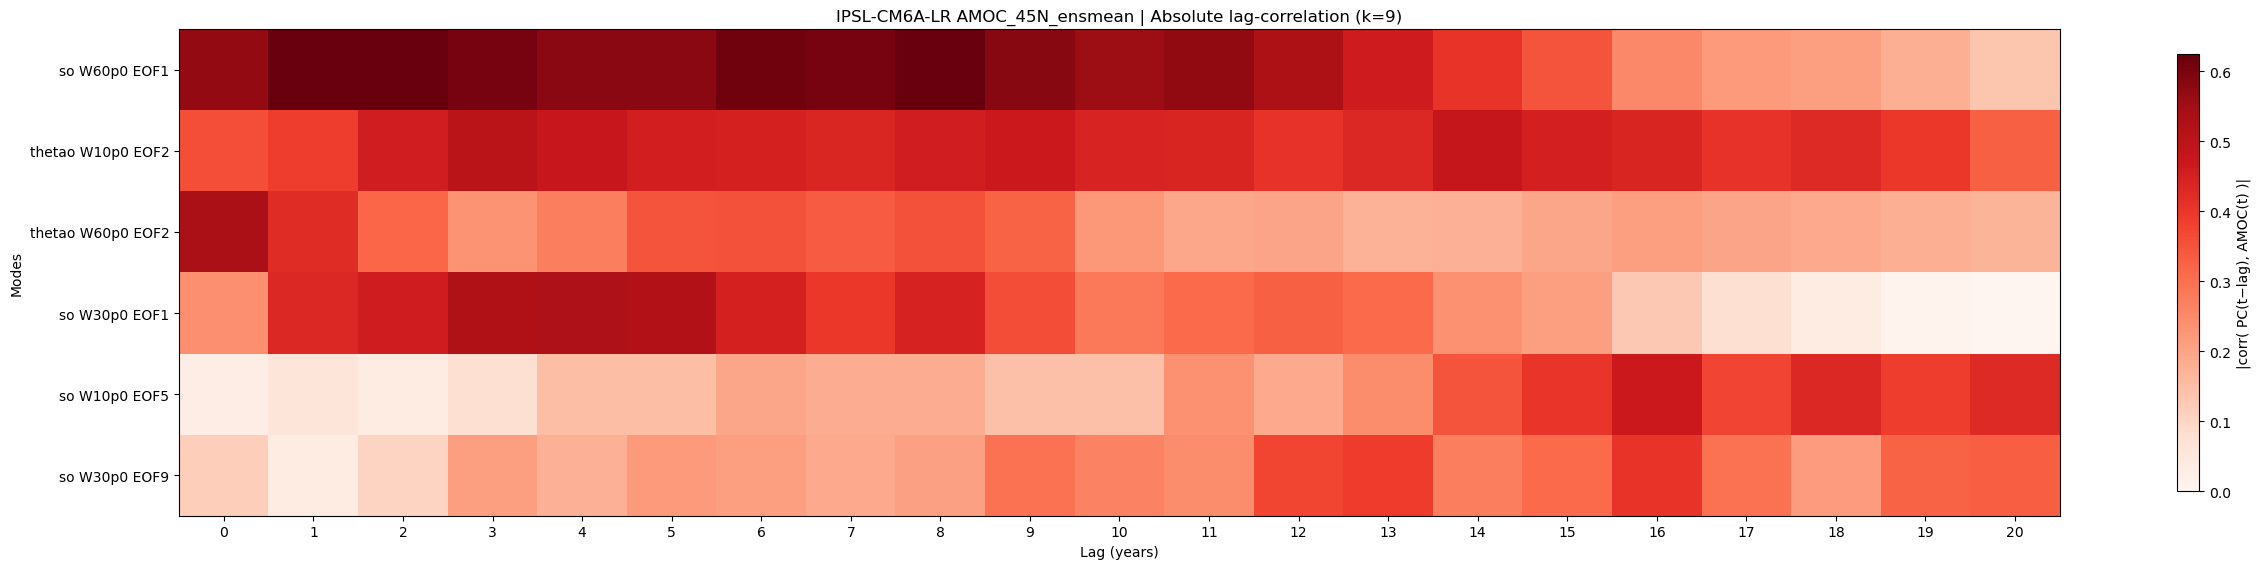

Saved heatmap: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_LAGCORR_HEATMAP/spike_modes_lagcorr_heatmap_k9_L20_train.png/.pdf


In [9]:
#!/usr/bin/env python3
"""
HEATMAP: lag-correlation for spike modes (from best_subsets_by_k.csv)
====================================================================

For each unique (var, lon, mode) in the chosen best subset (k=CHOOSE_K),
compute corr( PC_mode(t-lag), AMOC(t) ) for lag = 0..LAG_MAX
and plot a heatmap.

Outputs:
  - spike_modes_lagcorr_heatmap.png/.pdf
  - spike_modes_lagcorr_table.csv
"""

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"          # "ensmean" or "member"
member_id = None            # set if MODE="member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

BEST_CSV  = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_SUBSET_SEARCH/best_subsets_by_k.csv"
CHOOSE_K  = 9

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_LAGCORR_HEATMAP/"
os.makedirs(OUTDIR, exist_ok=True)

N_MODES = 10
LAG_MAX = 20                 # <- choose lag range here (0..LAG_MAX)

# Use the same detrend convention as your recon scripts:
DETREND_Y = True             # detrend AMOC using TRAIN-fit
DETREND_X = True             # detrend PC using TRAIN-fit

# Which years to correlate on:
CORR_ON = "train"            # "train" or "all"
# ----------------------------

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)  # (year, mode)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" in y.dims:
        yy = y
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in yy.coords and member_id in yy["member"].values:
                yy = yy.sel(member=member_id)
            else:
                yy = yy.isel(member=int(member_id))

    ds.close()
    return yy.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    return all_series - (a * all_years + b), (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]; b = b[m]
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    # unique (var,lon,mode0) preserve order
    uniq = []
    seen = set()
    for (v, lon, m0, _lag) in feats:
        key = (v, lon, int(m0))
        if key not in seen:
            uniq.append(key)
            seen.add(key)
    return uniq

def savefig(path_base, dpi=220):
    plt.savefig(path_base + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(path_base + ".pdf", dpi=dpi, bbox_inches="tight")

# ----------------------------
# 1) Get spike modes from best_subsets_by_k.csv
# ----------------------------
dfb = pd.read_csv(BEST_CSV)
row = dfb.loc[dfb["k"] == CHOOSE_K]
if len(row) != 1:
    raise ValueError(f"Could not uniquely find k={CHOOSE_K} in {BEST_CSV}. Available ks: {sorted(dfb['k'].unique())}")

modes_uniq = parse_features_string(row.iloc[0]["subset_features"])
if not modes_uniq:
    raise ValueError("No (var,lon,mode) parsed from subset_features.")

print("\nSpike modes (unique):")
for i, (v, lon, m0) in enumerate(modes_uniq, 1):
    print(f"  M{i}: {v} {lon} EOF{m0+1}")

# ----------------------------
# 2) Load AMOC + PCs + align years
# ----------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\nTRAIN_END_YEAR:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _m0) in modes_uniq))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y = amoc.sel(year=years).values.astype(float)

# train mask in full-year space
train_mask_full = years <= TRAIN_END_YEAR

# detrend AMOC (TRAIN-fit) if requested
if DETREND_Y:
    y_dt, (ay, by) = detrend_with_train_fit(years, y, train_mask_full)
else:
    y_dt = y.copy()

# choose correlation sample
if CORR_ON == "train":
    years_corr = years[train_mask_full]
    y_corr = y_dt[train_mask_full]
    # for indexing convenience, keep full arrays but restrict indices later
    corr_idx_full = np.where(train_mask_full)[0]
elif CORR_ON == "all":
    years_corr = years
    y_corr = y_dt
    corr_idx_full = np.arange(len(years), dtype=int)
else:
    raise ValueError("CORR_ON must be 'train' or 'all'")

# ----------------------------
# 3) Compute lag-correlation matrix
# ----------------------------
lags = np.arange(0, LAG_MAX + 1, dtype=int)
M = len(modes_uniq)
C = np.full((M, len(lags)), np.nan, float)

for i, (v, lon, m0) in enumerate(modes_uniq):
    PC = pc_dict[(v, lon)].sel(year=years)  # (year, mode)
    pc = PC.isel(mode=int(m0)).values.astype(float)

    # detrend PC (TRAIN-fit) if requested
    if DETREND_X:
        pc_dt, _ = detrend_with_train_fit(years, pc, train_mask_full)
    else:
        pc_dt = pc.copy()

    # compute corr for each lag: corr( pc[t-lag], y[t] )
    for j, lag in enumerate(lags):
        # valid indices t must satisfy: t-lag >= 0 and t in corr_idx_full
        t = corr_idx_full
        t = t[t - lag >= 0]
        if len(t) < 5:
            continue
        a = pc_dt[t - lag]
        b = y_dt[t]
        C[i, j] = pearson_corr(a, b)

# ----------------------------
# 4) Save CSV table
# ----------------------------
mode_labels = [f"{v} {lon} EOF{m0+1}" for (v, lon, m0) in modes_uniq]
df_out = pd.DataFrame(C, index=mode_labels, columns=[f"lag{L}" for L in lags])
csv_out = os.path.join(OUTDIR, f"spike_modes_lagcorr_table_k{CHOOSE_K}_L{LAG_MAX}.csv")
df_out.to_csv(csv_out)
print("\nSaved CSV:", csv_out)

# ----------------------------
# 5) Heatmap plot
# ----------------------------
fig, ax = plt.subplots(figsize=(1.0 * len(lags) + 4.5, 0.55 * M + 2.5))

C_abs = np.abs(C)

vmax = np.nanmax(C_abs)
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

# White -> red colormap
cmap = plt.cm.Reds

im = ax.imshow(
    C_abs,
    aspect="auto",
    vmin=0,
    vmax=vmax,
    cmap=cmap
)

ax.set_yticks(np.arange(M))
ax.set_yticklabels(mode_labels)

ax.set_xticks(np.arange(len(lags)))
ax.set_xticklabels([str(L) for L in lags])

ax.set_xlabel("Lag (years)")
ax.set_ylabel("Modes")
ax.set_title(
    f"{MODEL} {TARGET} | Absolute lag-correlation (k={CHOOSE_K})"
)

cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("|corr( PC(t−lag), AMOC(t) )|")

ax.grid(False)
fig.tight_layout()

outbase = os.path.join(OUTDIR, f"spike_modes_lagcorr_heatmap_k{CHOOSE_K}_L{LAG_MAX}_{CORR_ON}")
savefig(outbase)
plt.show()
print("Saved heatmap:", outbase + ".png/.pdf")


SPIKE SUBSET (chosen)
  S1: thetao W60p0 EOF2 lag0
  S2: so W60p0 EOF1 lag0
  S3: so W30p0 EOF1 lag4
  S4: so W10p0 EOF5 lag20
  S5: so W30p0 EOF1 lag3

✅ TRAIN_END_YEAR inferred from EOF files: 1989

Years: 1850–2014 (T=165)
Train: 1850–1989 (n=140)
Test : 1990–2014 (n=25)
✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_ANALYSIS/waterfall_steps_k5_greedy_best_first.csv


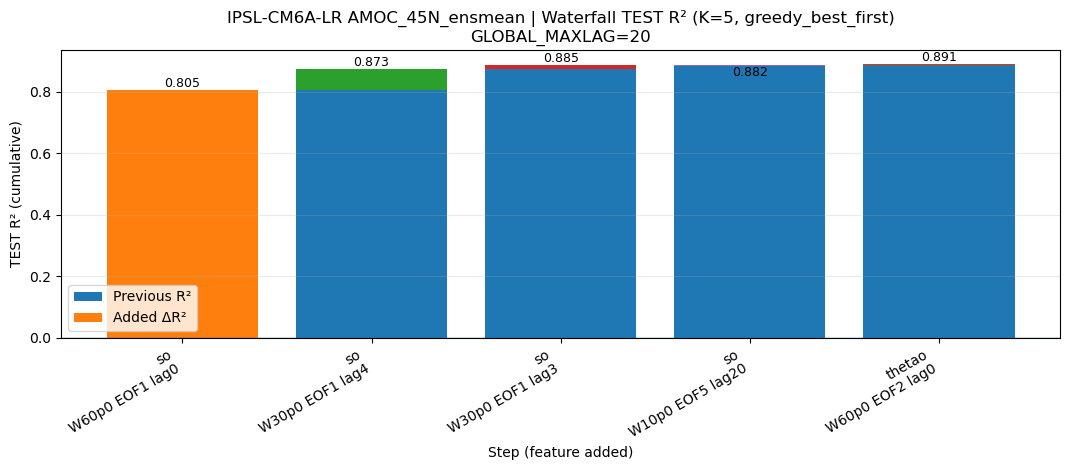

✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_ANALYSIS/waterfall_r2_k5.png/.pdf
✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_ANALYSIS/summary_k5_greedy_best_first.txt

DONE. Outputs in: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_ANALYSIS/


In [ ]:
#!/usr/bin/env python3
"""
SPIKE MODE ANALYSIS — HEATMAP (|corr|) + WATERFALL R² (stacked ΔR²)
===================================================================

What this script produces (for one chosen spike subset):
  (A) Heatmap of absolute lag-correlation |corr(PC_lag, AMOC)| for the spike modes
      - 0 is white, larger is red
      - computed on TRAIN window only (<= TRAIN_END_YEAR inferred from EOF files)
  (B) Waterfall (K bars) of TEST R²:
      - bar1 = best single spike feature
      - bar2 = best pair (greedy add)
      - ...
      - each bar is stacked: previous R² + colored ΔR² (new color each step)
  (C) CSV outputs for reproducibility

Important:
  - Uses fixed evaluation window via GLOBAL_MAXLAG to keep train/test years identical
  - Ridge regression, StandardScaler
  - Optional detrend (TRAIN-fit) for y and X columns

Author: ChatGPT (updated per Freja’s requests)
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import matplotlib.ticker as mticker
from matplotlib.colors import Normalize

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS (EDIT THESE)
# ============================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"          # "ensmean" or "member"
member_id = None            # if MODE="member": member label or index

# --- EOF + AMOC paths ---
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# --- Choose spike subset source ---
SPIKE_SUBSET_SOURCE = "best_csv"  # "best_csv" or "manual"

# If best_csv: pick K from the subset-search output (best_subsets_by_k.csv)
BEST_SUBSETS_CSV = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_SUBSET_SEARCH/best_subsets_by_k.csv"
CHOOSE_K_FROM_BESTCSV = 5

# If manual: define your spike subset explicitly as tuples: (var, lon, mode0, lag)
MANUAL_SPIKES = [
    # ("so", "W60p0", 0, 1),
    # ("thetao", "W10p0", 1, 16),
]

# --- Hyperparams for reconstruction scoring ---
ALPHA = 50.0
N_MODES = 10

# --- Detrending (TRAIN-fit) ---
DETREND_Y = True
DETREND_X = True

# --- Waterfall settings ---
K_WATERFALL = 5                 # number of bars
ORDER_MODE = "greedy_best_first" # "greedy_best_first" or "given_order"

# --- Output ---
OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/SPIKE_ANALYSIS/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided for mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)  # (year, mode)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" in y.dims:
        yy = y
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided for mode='member'")
            if "member" in yy.coords and member_id in yy["member"].values:
                yy = yy.sel(member=member_id)
            else:
                yy = yy.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()  # (year,)

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_features_string(s):
    """
    Parses strings like:
      "so W60p0 EOF1 lag3 | thetao W10p0 EOF2 lag16"
    Returns tuples: (var, lon, mode0, lag)
    """
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    if not feats:
        raise ValueError(f"Could not parse any features from: {s}")
    # deduplicate preserve order
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft); seen.add(ft)
    return out

def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

# ============================================================
# 0) Select spike subset
# ============================================================
if SPIKE_SUBSET_SOURCE == "manual":
    spike_feats = MANUAL_SPIKES
elif SPIKE_SUBSET_SOURCE == "best_csv":
    dfb = pd.read_csv(BEST_SUBSETS_CSV)
    row = dfb.loc[dfb["k"] == CHOOSE_K_FROM_BESTCSV]
    if len(row) != 1:
        raise ValueError(f"Could not uniquely find k={CHOOSE_K_FROM_BESTCSV} in {BEST_SUBSETS_CSV}. "
                         f"Available ks: {sorted(dfb['k'].unique())}")
    spike_feats = parse_features_string(row.iloc[0]["subset_features"])
else:
    raise ValueError("SPIKE_SUBSET_SOURCE must be 'best_csv' or 'manual'")

if not spike_feats:
    raise ValueError("No spike features selected.")

# K handling
K_WATERFALL = min(int(K_WATERFALL), len(spike_feats))

print("\n==============================")
print("SPIKE SUBSET (chosen)")
print("==============================")
for i, (v, lon, m0, lag) in enumerate(spike_feats, 1):
    print(f"  S{i}: {v} {lon} EOF{m0+1} lag{lag}")

# ============================================================
# 1) Load AMOC + PCs needed, align years
# ============================================================
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in spike_feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

# common years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# train mask in full-year space
train_mask_full = years <= TRAIN_END_YEAR
test_mask_full  = years >  TRAIN_END_YEAR

print(f"\nYears: {years[0]}–{years[-1]} (T={len(years)})")
print(f"Train: {years[train_mask_full][0]}–{years[train_mask_full][-1]} (n={train_mask_full.sum()})")
print(f"Test : {years[test_mask_full][0]}–{years[test_mask_full][-1]} (n={test_mask_full.sum()})")

# ============================================================
# 2) WATERFALL: greedy incremental TEST R² (stacked ΔR²)
# ============================================================
def score_subset_R2_test(feats_subset):
    """
    Score TEST R² for a subset of features, using:
      - GLOBAL_MAXLAG fixed by the subset itself (but we will override outside for fairness)
    This function assumes you've already built X_dt, Y_dt, idx_tr, idx_te outside.
    We'll instead build X columns from cached cand matrices to avoid recomputing.
    """
    raise RuntimeError("Internal placeholder; should not be called directly.")

# Candidate features for waterfall = the chosen spike feature tuples (including their lag)
cand_feats = spike_feats.copy()
M = len(cand_feats)

GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)
used_global = np.arange(GLOBAL_MAXLAG, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y (TRAIN-fit) if requested
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
else:
    Y_dt = Y_all.copy()
    ay, by = 0.0, 0.0

# Build candidate matrix (T_used, M)
X_cand = np.empty((len(used_global), M), dtype=float)
for j, (var, lon, m0, lag) in enumerate(cand_feats):
    X_cand[:, j] = pc_np[(var, lon)][used_global - lag, int(m0)]

# Detrend X columns (TRAIN-fit) if requested
if DETREND_X:
    X_dt = X_cand.copy()
    for j in range(M):
        X_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
else:
    X_dt = X_cand.copy()

def eval_subset(subset_idx):
    subset_idx = tuple(subset_idx)
    Xk = X_dt[:, subset_idx]
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
    mdl.fit(Xk[idx_tr], Y_dt[idx_tr])
    pred_te = mdl.predict(Xk[idx_te])
    r2_te = float(r2_score(Y_dt[idx_te], pred_te))
    c_te  = pearson_corr(Y_dt[idx_te], pred_te)
    return r2_te, c_te

def feat_to_str(ft):
    v, lon, m0, lag = ft
    return f"{v} {lon} EOF{int(m0)+1} lag{int(lag)}"

# ---- Build order & steps ----
steps = []
chosen = []
remaining = list(range(M))

prev_r2 = 0.0

if ORDER_MODE == "given_order":
    # just take the first K_WATERFALL in the given order
    order = list(range(min(K_WATERFALL, M)))
    for s, idx in enumerate(order, 1):
        chosen.append(idx)
        r2_te, c_te = eval_subset(chosen)
        delta = r2_te - prev_r2
        steps.append(dict(
            step=s,
            added_index=idx,
            added_feature=feat_to_str(cand_feats[idx]),
            r2_test=r2_te,
            corr_test=c_te,
            delta_r2_test=delta,
            features_used=" | ".join([feat_to_str(cand_feats[i]) for i in chosen])
        ))
        prev_r2 = r2_te
else:
    # greedy best-first: at each step add the remaining feature that maximizes TEST R²
    for s in range(1, K_WATERFALL + 1):
        best_idx = None
        best_r2  = -np.inf
        best_c   = np.nan

        for idx in remaining:
            trial = chosen + [idx]
            r2_te, c_te = eval_subset(trial)
            if r2_te > best_r2:
                best_r2 = r2_te
                best_c  = c_te
                best_idx = idx

        chosen.append(best_idx)
        remaining.remove(best_idx)

        delta = best_r2 - prev_r2
        steps.append(dict(
            step=s,
            added_index=best_idx,
            added_feature=feat_to_str(cand_feats[best_idx]),
            r2_test=best_r2,
            corr_test=best_c,
            delta_r2_test=delta,
            features_used=" | ".join([feat_to_str(cand_feats[i]) for i in chosen])
        ))
        prev_r2 = best_r2

df_steps = pd.DataFrame(steps)

steps_csv = os.path.join(OUTDIR, f"waterfall_steps_k{K_WATERFALL}_{ORDER_MODE}.csv")
df_steps.to_csv(steps_csv, index=False)
print("✅ Saved:", steps_csv)

# ---- Plot waterfall (stacked base + colored increment) ----
def plot_r2_waterfall(df_steps, outbase, title):
    K = len(df_steps)
    r2 = df_steps["r2_test"].values.astype(float)
    delta = df_steps["delta_r2_test"].values.astype(float)
    x = np.arange(1, K + 1)

    fig, ax = plt.subplots(figsize=(10.8, 4.8))

    base = np.zeros(K, dtype=float)
    if K > 1:
        base[1:] = r2[:-1]

    # base bars (previous R²)
    ax.bar(x, base, label="Previous R²")

    # delta bars (new color each step)
    for i in range(K):
        ax.bar(
            x[i],
            delta[i],
            bottom=base[i],
            label="Added ΔR²" if i == 0 else None
        )
        # annotate cumulative
        ax.text(
            x[i],
            base[i] + delta[i],
            f"{r2[i]:.3f}",
            ha="center",
            va="bottom" if delta[i] >= 0 else "top",
            fontsize=9
        )

    ax.axhline(0, linewidth=1)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xticks(x)
    # Build readable feature labels
    feat_labels = [
        df_steps.iloc[i]["added_feature"]
        for i in range(K)
    ]

    # Optional: make them shorter / cleaner
    feat_labels = [
        lbl.replace(" ", "\n", 1)  # put variable on first line
        for lbl in feat_labels
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(feat_labels, rotation=30, ha="right")
    
    ax.set_xlabel("Step (feature added)")
    ax.set_ylabel("TEST R² (cumulative)")
    ax.set_title(title)
    ax.legend(loc="best")

    fig.tight_layout()
    savefig(outbase)
    plt.show()

titleW = (f"{MODEL} {TARGET} | Waterfall TEST R² (K={K_WATERFALL}, {ORDER_MODE})\n"
          f"GLOBAL_MAXLAG={GLOBAL_MAXLAG}")

outW = os.path.join(OUTDIR, f"waterfall_r2_k{K_WATERFALL}")
plot_r2_waterfall(df_steps, outW, titleW)
print("✅ Saved:", outW + ".png/.pdf")

# Also write a short text summary
summary_txt = os.path.join(OUTDIR, f"summary_k{K_WATERFALL}_{ORDER_MODE}.txt")
with open(summary_txt, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\n")
    f.write(f"GLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"ORDER_MODE={ORDER_MODE}\nK_WATERFALL={K_WATERFALL}\n")
    f.write("\nChosen spike subset (input):\n")
    for ft in spike_feats:
        f.write("  " + feat_to_str(ft) + "\n")
    f.write("\nGreedy / chosen order + scores:\n")
    for _, r in df_steps.iterrows():
        f.write(f"\nSTEP {int(r.step)}  R2_test={r.r2_test:.6f}  ΔR2={r.delta_r2_test:+.6f}  corr={r.corr_test:.6f}\n")
        f.write(f"Added: {r.added_feature}\n")
        f.write(f"Set:   {r.features_used}\n")

print("✅ Saved:", summary_txt)
print("\nDONE. Outputs in:", OUTDIR)